In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path.cwd()
while not (project_root / 'pyproject.toml').exists() and project_root != project_root.parent:
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

In [2]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.analysis import Circle
from src.data.detector import DetectorData

## Configuration

In [3]:
# Data path - single large foil from 2025-11-25
DATA_PATH = Path(r"C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25")
INPUT_FILE = DATA_PATH / 'mbo_aic144_single_foil_processed.pkl'

# Visualization parameters
PIXEL_SIZE_MM = 0.074         # Pixel size in mm
LOW_THRESHOLD_VALUE = 50      # Pixel value below which pixels are white

## Load Processed Data

In [4]:
# Load processed foil data (includes refined circle)
with open(INPUT_FILE, 'rb') as f:
    foil_data: DetectorData = pickle.load(f)

print(f"Loaded data from: {INPUT_FILE}")
print(f"  Image shape: {foil_data.raw.image.shape}")
print(f"  Image size: {foil_data.raw.image.shape[0] * PIXEL_SIZE_MM:.1f} x {foil_data.raw.image.shape[1] * PIXEL_SIZE_MM:.1f} mm")
print(f"  Refined circle: center=({foil_data.circle.x:.1f}, {foil_data.circle.y:.1f}) px")
print(f"                  center=({foil_data.circle.x * PIXEL_SIZE_MM:.2f}, {foil_data.circle.y * PIXEL_SIZE_MM:.2f}) mm")
print(f"                  radius={foil_data.circle.r:.1f} px = {foil_data.circle.r * PIXEL_SIZE_MM:.2f} mm")

Loaded data from: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_processed.pkl
  Image shape: (1024, 1024)
  Image size: 75.8 x 75.8 mm
  Refined circle: center=(532.2, 499.5) px
                  center=(39.38, 36.96) mm
                  radius=241.6 px = 17.88 mm


## Rotate Image 180 Degrees

In [5]:
# Rotate image 180 degrees (equivalent to np.rot90 twice)
image_original = foil_data.raw.image
image_rotated = np.rot90(image_original, k=2)  # k=2 means 180 degree rotation

# Update circle center after 180 degree rotation
# (x, y) -> (width - x, height - y)
h, w = image_original.shape
circle_original = foil_data.circle
circle_rotated = Circle(
    x=w - circle_original.x,
    y=h - circle_original.y,
    r=circle_original.r
)

print(f"Original image shape: {image_original.shape}")
print(f"Rotated image shape: {image_rotated.shape}")
print(f"\nOriginal circle center: ({circle_original.x:.1f}, {circle_original.y:.1f}) px")
print(f"Rotated circle center:  ({circle_rotated.x:.1f}, {circle_rotated.y:.1f}) px")

Original image shape: (1024, 1024)
Rotated image shape: (1024, 1024)

Original circle center: (532.2, 499.5) px
Rotated circle center:  (491.8, 524.5) px


## Visualization Functions

In [6]:
def create_white_green_red_cmap():
    """Colormap: white→green→red. Set values below threshold to NaN for white."""
    cmap = LinearSegmentedColormap.from_list('wgr', ['white', 'green', 'red'])
    cmap.set_bad('white')
    return cmap


def plot_foil_with_profiles(image, circle, px_mm, threshold, title="", margin_mm=4.0):
    """Plot foil cropped to circle with margin, colormap and profiles."""
    h, w = image.shape
    cx, cy = int(circle.x), int(circle.y)
    r_mm = circle.r * px_mm
    
    # Crop region: circle ± (radius + margin)
    margin_px = int(margin_mm / px_mm)
    r_px = int(circle.r)
    x0 = max(0, cx - r_px - margin_px)
    x1 = min(w, cx + r_px + margin_px)
    y0 = max(0, cy - r_px - margin_px)
    y1 = min(h, cy + r_px + margin_px)
    
    # Crop image and adjust coordinates
    img_crop = image[y0:y1, x0:x1].astype(np.float32).copy()
    cx_crop, cy_crop = cx - x0, cy - y0
    hc, wc = img_crop.shape
    
    # Extent in mm (relative to crop origin)
    extent = [0, wc * px_mm, hc * px_mm, 0]
    cx_mm, cy_mm = cx_crop * px_mm, cy_crop * px_mm
    
    vmax = np.nanmax(img_crop)
    img_crop[img_crop < threshold] = np.nan
    
    # Extract profiles from cropped image
    pw = 5
    h_profile = image[y0:y1, x0:x1][max(0,cy_crop-pw):min(hc,cy_crop+pw), :].mean(axis=0)
    v_profile = image[y0:y1, x0:x1][:, max(0,cx_crop-pw):min(wc,cx_crop+pw)].mean(axis=1)
    x_mm, y_mm = np.arange(wc) * px_mm, np.arange(hc) * px_mm
    
    # Create figure
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_axes([0.1, 0.35, 0.6, 0.55])
    ax_h = fig.add_axes([0.1, 0.08, 0.6, 0.22])
    ax_v = fig.add_axes([0.73, 0.35, 0.12, 0.55])
    ax_cb = fig.add_axes([0.73, 0.08, 0.02, 0.22])
    
    # Main image
    im = ax.imshow(img_crop, cmap=create_white_green_red_cmap(), vmin=0, vmax=vmax, extent=extent, aspect='equal')
    ax.axhline(cy_mm, c='k', lw=1.5, alpha=0.8)
    ax.axvline(cx_mm, c='k', lw=1.5, alpha=0.8)
    if circle.r > 0:
        ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
        ax.scatter(cx_mm, cy_mm, c='blue', s=50, marker='+', lw=2)
    
    # 5mm grid
    ax.set_xticks(np.arange(0, extent[1], 5))
    ax.set_yticks(np.arange(0, extent[2], 5))
    ax.grid(True, lw=0.5, c='k', alpha=0.3)
    ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
    
    # Horizontal profile
    ax_h.plot(x_mm, h_profile, 'b-', lw=1)
    ax_h.axvline(cx_mm, c='r', ls='--', alpha=0.7)
    if circle.r > 0:
        ax_h.axvline(cx_mm - r_mm, c='g', ls=':', alpha=0.7)
        ax_h.axvline(cx_mm + r_mm, c='g', ls=':', alpha=0.7)
    ax_h.set(xlabel='x [mm]', ylabel='Value', xlim=(0, extent[1]))
    ax_h.grid(True, lw=0.5, c='k', alpha=0.3)
    
    # Vertical profile
    ax_v.plot(v_profile, y_mm, 'b-', lw=1)
    ax_v.axhline(cy_mm, c='r', ls='--', alpha=0.7)
    if circle.r > 0:
        ax_v.axhline(cy_mm - r_mm, c='g', ls=':', alpha=0.7)
        ax_v.axhline(cy_mm + r_mm, c='g', ls=':', alpha=0.7)
    ax_v.set(xlabel='Value', ylabel='y [mm]', ylim=(extent[2], 0))
    ax_v.grid(True, lw=0.5, c='k', alpha=0.3)
    
    plt.colorbar(im, cax=ax_cb, label='Value')
    plt.show()

## Rotated Image Visualization

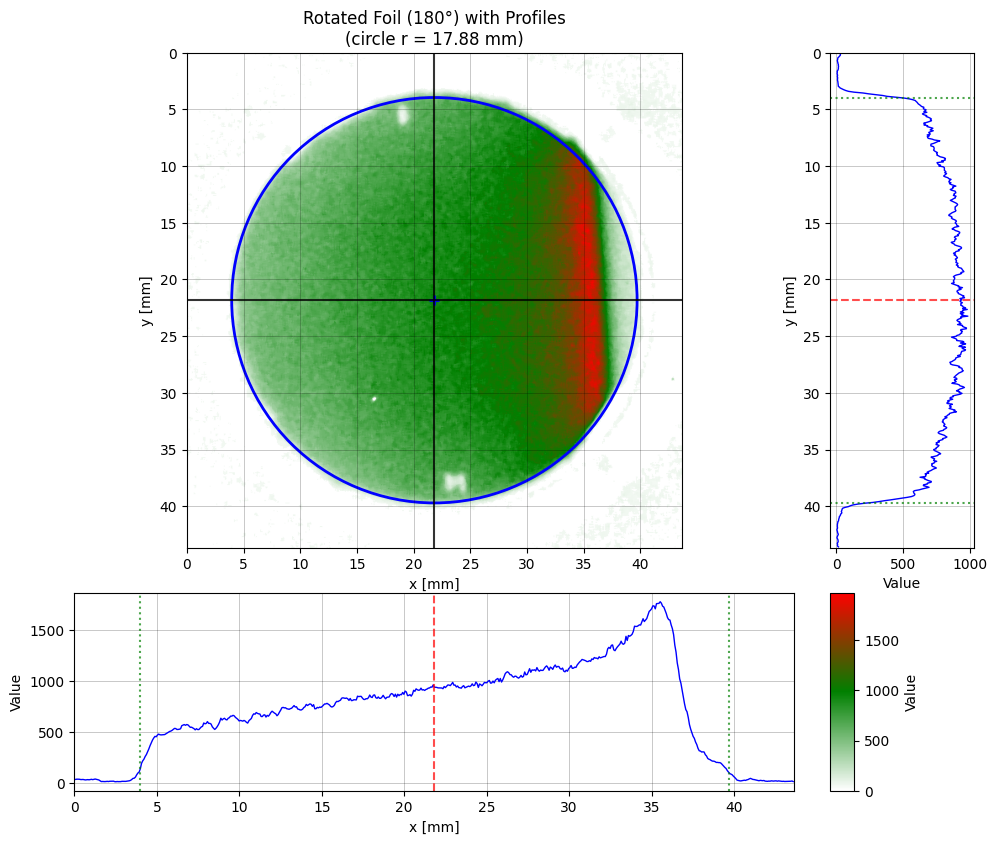

In [7]:
# Plot rotated image with profiles through refined circle center
plot_foil_with_profiles(
    image_rotated, 
    circle_rotated, 
    PIXEL_SIZE_MM,
    LOW_THRESHOLD_VALUE,
    title=f'Rotated Foil (180°) with Profiles\n(circle r = {circle_rotated.r * PIXEL_SIZE_MM:.2f} mm)'
)

## Iso-signal Contours (Smoothed)

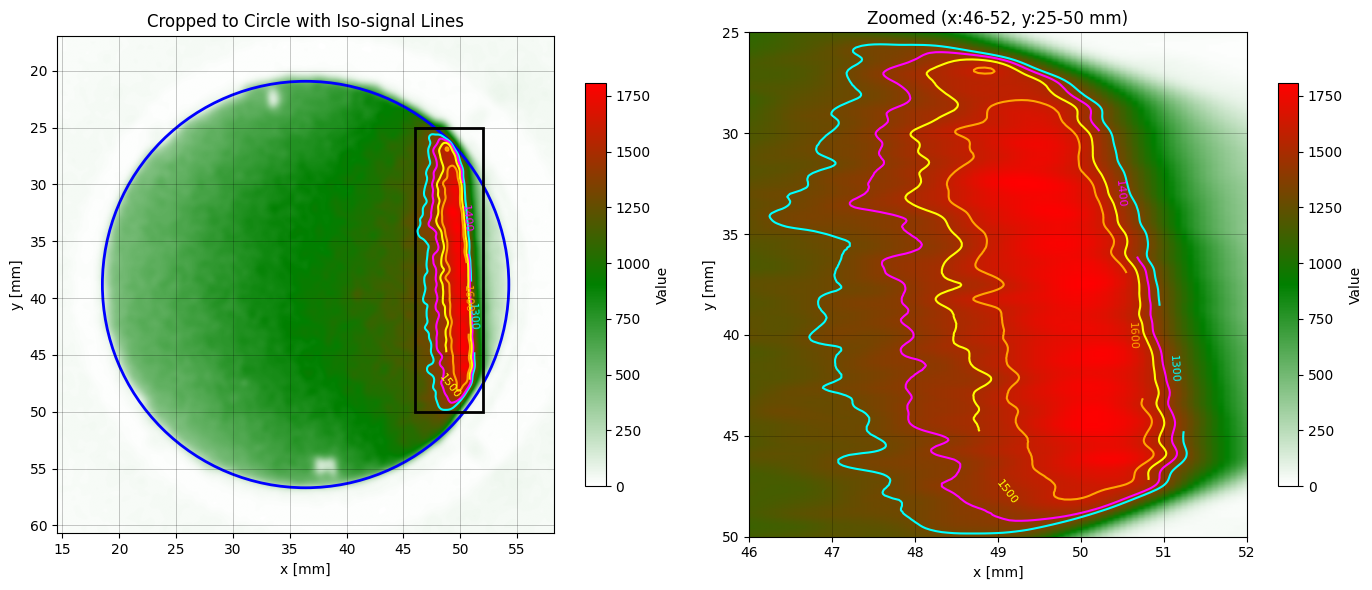

In [8]:
# Aggressive smoothing to remove salt & pepper noise
import scipy.ndimage as ndi
img_smooth = ndi.median_filter(image_rotated, size=7)
img_smooth = ndi.gaussian_filter(img_smooth, sigma=3)

h, w = img_smooth.shape
x_mm, y_mm = np.arange(w) * PIXEL_SIZE_MM, np.arange(h) * PIXEL_SIZE_MM
extent = [0, w * PIXEL_SIZE_MM, h * PIXEL_SIZE_MM, 0]
levels = [1300, 1400, 1500, 1600]

# Zoom limits
margin_mm = 4.0
cx_mm, cy_mm = circle_rotated.x * PIXEL_SIZE_MM, circle_rotated.y * PIXEL_SIZE_MM
r_mm = circle_rotated.r * PIXEL_SIZE_MM
xlim_crop = (cx_mm - r_mm - margin_mm, cx_mm + r_mm + margin_mm)
ylim_crop = (cy_mm + r_mm + margin_mm, cy_mm - r_mm - margin_mm)
zoom_xlim, zoom_ylim = (46, 52), (50, 25)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = create_white_green_red_cmap()

for i, (ax, xlim, ylim, aspect, title) in enumerate([
    (axes[0], xlim_crop, ylim_crop, 'equal', 'Cropped to Circle with Iso-signal Lines'),
    (axes[1], zoom_xlim, zoom_ylim, 'auto', f'Zoomed (x:{zoom_xlim[0]}-{zoom_xlim[1]}, y:{zoom_ylim[1]}-{zoom_ylim[0]} mm)')
]):
    im = ax.imshow(img_smooth, cmap=cmap, extent=extent, aspect=aspect)
    cs = ax.contour(x_mm, y_mm, img_smooth, levels=levels, colors=['cyan', 'magenta', 'yellow', 'orange'], linewidths=1.5)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
    ax.grid(True, lw=0.5, c='k', alpha=0.3)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Value')
    
    if i == 0:  # Left plot: add circle and zoom rectangle
        ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle((zoom_xlim[0], zoom_ylim[1]), zoom_xlim[1]-zoom_xlim[0], 
                                zoom_ylim[0]-zoom_ylim[1], ec='black', fc='none', lw=2))

plt.tight_layout()
plt.show()

## Gravity Centers Analysis

In [9]:
# Configuration
THRESHOLD_VALUE = 1400
Y_MIN_MM, Y_MAX_MM = 25, 50  # same as zoom
SLICE_WIDTH_MM = 1.0

# Calculate gravity centers for each Y slice
n_slices = int((Y_MAX_MM - Y_MIN_MM) / SLICE_WIDTH_MM)
gravity_centers = []

for i in range(n_slices):
    y_start_mm = Y_MIN_MM + i * SLICE_WIDTH_MM
    y_end_mm = y_start_mm + SLICE_WIDTH_MM
    
    # Convert to pixels
    y_start_px = int(y_start_mm / PIXEL_SIZE_MM)
    y_end_px = int(y_end_mm / PIXEL_SIZE_MM)
    
    # Extract slice and apply threshold
    slice_data = img_smooth[y_start_px:y_end_px, :].copy()
    mask = slice_data > THRESHOLD_VALUE
    
    if mask.any():
        # Get coordinates of pixels above threshold
        y_idx, x_idx = np.where(mask)
        values = slice_data[mask]
        
        # Calculate weighted center of mass
        total = values.sum()
        x_center_px = (x_idx * values).sum() / total
        y_center_px = y_start_px + (y_idx * values).sum() / total
        
        # Convert to mm
        gravity_centers.append((x_center_px * PIXEL_SIZE_MM, y_center_px * PIXEL_SIZE_MM))

gravity_centers = np.array(gravity_centers)
print(f"Found {len(gravity_centers)} gravity centers from {n_slices} slices")

# Fit X = a*Y + b
fit_coeffs = np.polyfit(gravity_centers[:, 1], gravity_centers[:, 0], 1)  # Y -> X
fit_a, fit_b = fit_coeffs

# Calculate angle from vertical (vertical line has slope = infinity, i.e. dX/dY = 0)
# Our line has slope a = dX/dY, angle from vertical = arctan(a)
angle_from_vertical = np.degrees(np.arctan(fit_a))

print(f"Fitted line: X = {fit_a:.4f} * Y + {fit_b:.2f}")
print(f"Angle from vertical: {angle_from_vertical:.2f}°")

Found 24 gravity centers from 25 slices
Fitted line: X = 0.0433 * Y + 47.64
Angle from vertical: 2.48°


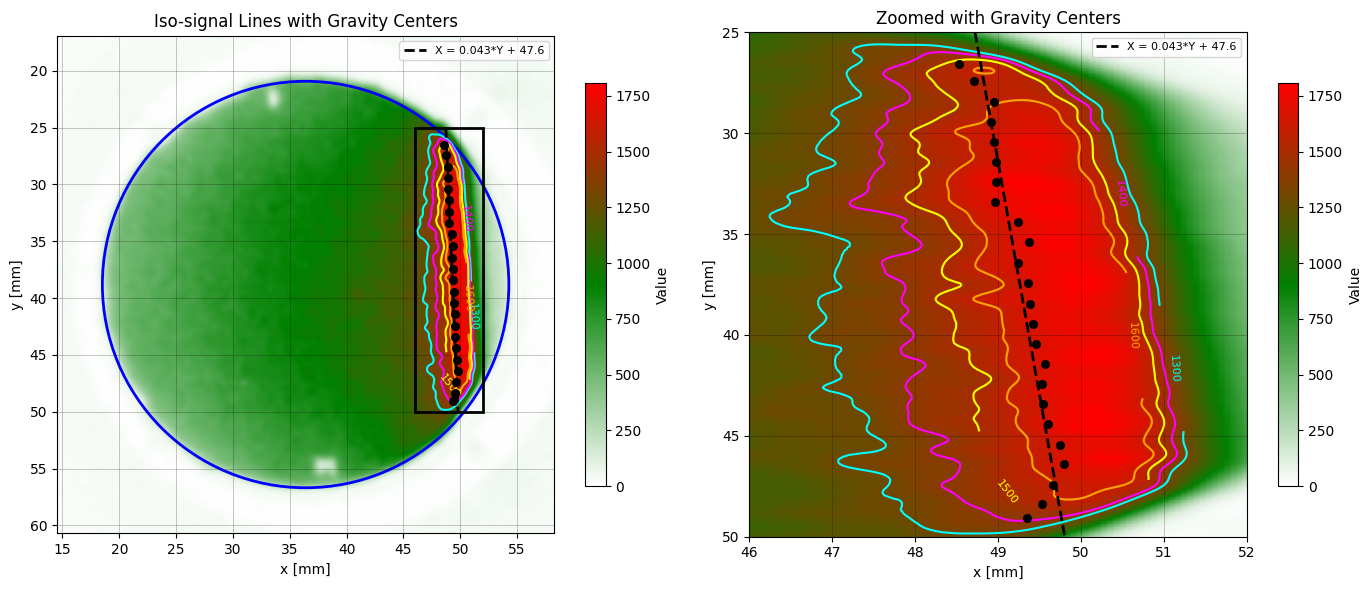

In [10]:
# Plot with gravity centers
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = create_white_green_red_cmap()

# Fitted line points
y_fit = np.array([Y_MIN_MM, Y_MAX_MM])
x_fit = fit_a * y_fit + fit_b

for i, (ax, xlim, ylim, aspect, title) in enumerate([
    (axes[0], xlim_crop, ylim_crop, 'equal', 'Iso-signal Lines with Gravity Centers'),
    (axes[1], zoom_xlim, zoom_ylim, 'auto', f'Zoomed with Gravity Centers')
]):
    im = ax.imshow(img_smooth, cmap=cmap, extent=extent, aspect=aspect)
    cs = ax.contour(x_mm, y_mm, img_smooth, levels=levels, colors=['cyan', 'magenta', 'yellow', 'orange'], linewidths=1.5)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.scatter(gravity_centers[:, 0], gravity_centers[:, 1], c='black', s=30, zorder=5)
    ax.plot(x_fit, y_fit, 'k--', lw=2, label=f'X = {fit_a:.3f}*Y + {fit_b:.1f}')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
    ax.grid(True, lw=0.5, c='k', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Value')
    
    if i == 0:
        ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle((zoom_xlim[0], zoom_ylim[1]), zoom_xlim[1]-zoom_xlim[0], 
                                zoom_ylim[0]-zoom_ylim[1], ec='black', fc='none', lw=2))

plt.tight_layout()
plt.show()

## Rotation Optimization

Find optimal rotation angle to minimize tilt (angle from vertical ≈ 0)

In [11]:
# ============ ROTATION OPTIMIZATION CONFIG ============
ROT_ANGLE_MIN, ROT_ANGLE_MAX = -5.0, 5.0  # degrees
ROT_N_STEPS = 100                         # brute-force grid points
ROT_THRESHOLD = 1400
ROT_Y_MIN_MM, ROT_Y_MAX_MM = 25, 50
ROT_SLICE_MM = 1.0
BISECT_TOL = 0.01                         # bisection convergence tolerance [degrees]
OPT_METHOD = 'bisection'                  # 'bisection' or 'bruteforce'
PROFILE_STRIPE_MM = 5.0                   # central stripe thickness for horizontal profile

In [12]:
import time
from scipy.ndimage import rotate as ndi_rotate

def rotate_around_center(image, angle_deg, center_px):
    """Rotate image around specified center, pad with zeros."""
    h, w = image.shape
    cx, cy = center_px
    shift_y, shift_x = h/2 - cy, w/2 - cx
    shifted = ndi.shift(image, [shift_y, shift_x], mode='constant', cval=0)
    rotated = ndi_rotate(shifted, angle_deg, reshape=False, mode='constant', cval=0)
    return ndi.shift(rotated, [-shift_y, -shift_x], mode='constant', cval=0)

def calc_angle_from_vertical(img_smooth, threshold, y_min_mm, y_max_mm, slice_mm, px_mm):
    """Calculate angle from vertical for gravity centers (returns signed angle)."""
    n_slices = int((y_max_mm - y_min_mm) / slice_mm)
    centers = []
    for i in range(n_slices):
        y0_px, y1_px = int((y_min_mm + i*slice_mm) / px_mm), int((y_min_mm + (i+1)*slice_mm) / px_mm)
        slc = img_smooth[y0_px:y1_px, :]
        mask = slc > threshold
        if mask.any():
            y_idx, x_idx = np.where(mask)
            vals = slc[mask]
            centers.append(((x_idx * vals).sum() / vals.sum() * px_mm,
                           (y0_px + (y_idx * vals).sum() / vals.sum()) * px_mm))
    if len(centers) < 2:
        return np.inf, np.array([])
    centers = np.array(centers)
    fit_a = np.polyfit(centers[:, 1], centers[:, 0], 1)[0]
    return np.degrees(np.arctan(fit_a)), centers

def eval_rotation(angle, image, center_px, threshold, y_min, y_max, slice_mm, px_mm):
    """Evaluate angle from vertical for given rotation."""
    img_rot = rotate_around_center(image, angle, center_px)
    img_sm = ndi.gaussian_filter(ndi.median_filter(img_rot, size=7), sigma=3)
    return calc_angle_from_vertical(img_sm, threshold, y_min, y_max, slice_mm, px_mm)[0]

center_px = (circle_rotated.x, circle_rotated.y)

In [13]:
# Brute-force scan with progress (only if selected)
if OPT_METHOD == 'bruteforce':
    print(f"Brute-force scan: {ROT_N_STEPS} points from {ROT_ANGLE_MIN}° to {ROT_ANGLE_MAX}°")
    angles_bf = np.linspace(ROT_ANGLE_MIN, ROT_ANGLE_MAX, ROT_N_STEPS)
    cost_values_bf = []

    t0 = time.time()
    for idx, angle in enumerate(angles_bf):
        angle_vert = eval_rotation(angle, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
        cost_values_bf.append(abs(angle_vert))
        if (idx + 1) % 20 == 0 or idx == 0:
            print(f"  [{idx+1:3d}/{ROT_N_STEPS}] angle={angle:+.2f}°, |vert|={abs(angle_vert):.4f}°, elapsed={time.time()-t0:.1f}s")

    cost_values_bf = np.array(cost_values_bf)
    best_idx_bf = np.argmin(cost_values_bf)
    best_angle_bf = angles_bf[best_idx_bf]
    bf_time = time.time() - t0

    print(f"\nBrute-force: {bf_time:.1f}s, optimal={best_angle_bf:.4f}°, |vert|={cost_values_bf[best_idx_bf]:.4f}°")
else:
    print(f"Skipping brute-force (OPT_METHOD='{OPT_METHOD}')")

Skipping brute-force (OPT_METHOD='bisection')


In [14]:
# Plot brute-force cost function (only if method was used)
if OPT_METHOD == 'bruteforce':
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(angles_bf, cost_values_bf, 'b-', lw=1.5)
    ax.axvline(best_angle_bf, c='r', ls='--', lw=2, label=f'Best: {best_angle_bf:.3f}°')
    ax.scatter([best_angle_bf], [cost_values_bf[best_idx_bf]], c='r', s=100, zorder=5)
    ax.set(xlabel='Rotation angle [°]', ylabel='|Angle from vertical| [°]', 
           title=f'Brute-Force Optimization ({ROT_N_STEPS} pts, {bf_time:.1f}s)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

In [15]:
# Bisection method (only if selected)
if OPT_METHOD == 'bisection':
    print(f"Bisection method: tolerance={BISECT_TOL}°")
    t0 = time.time()

    a, b = ROT_ANGLE_MIN, ROT_ANGLE_MAX
    fa = eval_rotation(a, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
    fb = eval_rotation(b, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
    print(f"  Initial: f({a})={fa:+.4f}°, f({b})={fb:+.4f}°")

    if fa * fb > 0:
        print("  WARNING: No sign change detected, bisection may not converge!")

    bisect_history = [(a, fa), (b, fb)]
    iteration = 0

    while (b - a) > BISECT_TOL:
        iteration += 1
        mid = (a + b) / 2
        fmid = eval_rotation(mid, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
        bisect_history.append((mid, fmid))
        
        if fa * fmid < 0:
            b, fb = mid, fmid
        else:
            a, fa = mid, fmid
        
        print(f"  [{iteration:2d}] interval=[{a:+.4f}, {b:+.4f}], mid={mid:+.4f}°, f(mid)={fmid:+.6f}°")

    best_angle_bisect = (a + b) / 2
    bisect_time = time.time() - t0
    final_vert = eval_rotation(best_angle_bisect, image_rotated, center_px, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)
    bisect_history_arr = np.array(bisect_history)

    print(f"\nBisection: {bisect_time:.1f}s, {iteration} iterations, optimal={best_angle_bisect:.4f}°, |vert|={abs(final_vert):.4f}°")
else:
    print(f"Skipping bisection (OPT_METHOD='{OPT_METHOD}')")

Bisection method: tolerance=0.01°
  Initial: f(-5.0)=-2.0870°, f(5.0)=+7.3228°
  [ 1] interval=[-5.0000, +0.0000], mid=+0.0000°, f(mid)=+2.489888°
  [ 2] interval=[-5.0000, -2.5000], mid=-2.5000°, f(mid)=+0.320398°
  [ 3] interval=[-3.7500, -2.5000], mid=-3.7500°, f(mid)=-0.756370°
  [ 4] interval=[-3.1250, -2.5000], mid=-3.1250°, f(mid)=-0.235851°
  [ 5] interval=[-3.1250, -2.8125], mid=-2.8125°, f(mid)=+0.061720°
  [ 6] interval=[-2.9688, -2.8125], mid=-2.9688°, f(mid)=-0.084016°
  [ 7] interval=[-2.8906, -2.8125], mid=-2.8906°, f(mid)=-0.021297°
  [ 8] interval=[-2.8906, -2.8516], mid=-2.8516°, f(mid)=+0.025376°
  [ 9] interval=[-2.8906, -2.8711], mid=-2.8711°, f(mid)=+0.010938°
  [10] interval=[-2.8906, -2.8809], mid=-2.8809°, f(mid)=+0.001458°

Bisection: 14.4s, 10 iterations, optimal=-2.8857°, |vert|=0.0095°


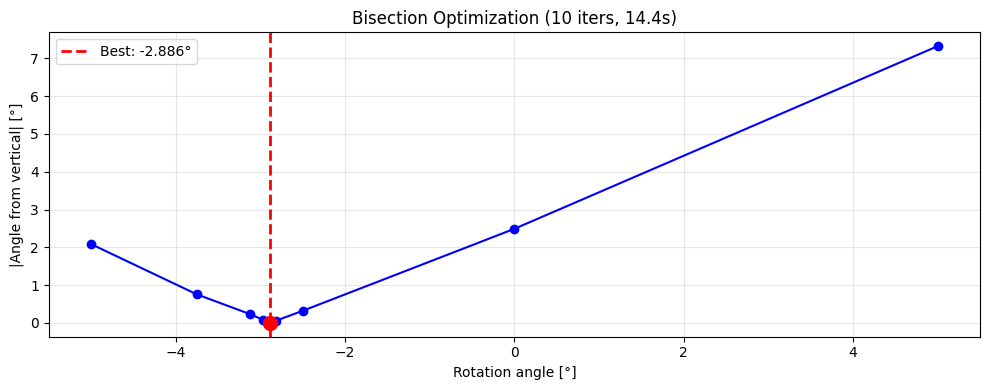

In [16]:
# Plot bisection cost function (only if method was used)
if OPT_METHOD == 'bisection':
    fig, ax = plt.subplots(figsize=(10, 4))
    sorted_idx = np.argsort(bisect_history_arr[:, 0])
    ax.plot(bisect_history_arr[sorted_idx, 0], np.abs(bisect_history_arr[sorted_idx, 1]), 'bo-', lw=1.5, ms=6)
    ax.axvline(best_angle_bisect, c='r', ls='--', lw=2, label=f'Best: {best_angle_bisect:.3f}°')
    ax.scatter([best_angle_bisect], [abs(final_vert)], c='r', s=100, zorder=5)
    ax.set(xlabel='Rotation angle [°]', ylabel='|Angle from vertical| [°]', 
           title=f'Bisection Optimization ({iteration} iters, {bisect_time:.1f}s)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

Using bisection method: best_angle = -2.8857° (computed in 14.4s)
After rotation by -2.886°:
  Fitted line: X = -0.000166 * Y + 49.32
  Angle from vertical: -0.0095°


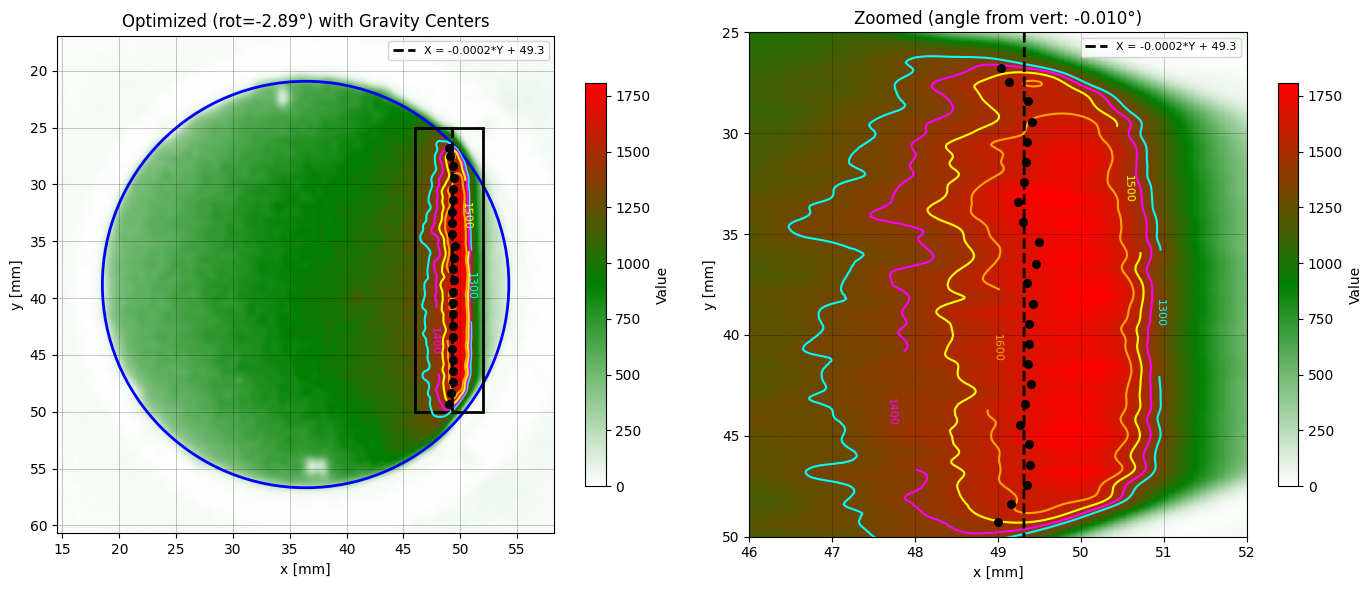

In [17]:
# Apply optimal rotation (using selected method) and recalculate
best_angle = best_angle_bisect if OPT_METHOD == 'bisection' else best_angle_bf
opt_time = bisect_time if OPT_METHOD == 'bisection' else bf_time
print(f"Using {OPT_METHOD} method: best_angle = {best_angle:.4f}° (computed in {opt_time:.1f}s)")

img_optimized = rotate_around_center(image_rotated, best_angle, center_px)
img_opt_smooth = ndi.gaussian_filter(ndi.median_filter(img_optimized, size=7), sigma=3)
opt_angle_vert, opt_centers = calc_angle_from_vertical(img_opt_smooth, ROT_THRESHOLD, ROT_Y_MIN_MM, ROT_Y_MAX_MM, ROT_SLICE_MM, PIXEL_SIZE_MM)

# Fit line for optimized image
opt_fit_a, opt_fit_b = np.polyfit(opt_centers[:, 1], opt_centers[:, 0], 1)
y_fit = np.array([ROT_Y_MIN_MM, ROT_Y_MAX_MM])
x_fit = opt_fit_a * y_fit + opt_fit_b

print(f"After rotation by {best_angle:.3f}°:")
print(f"  Fitted line: X = {opt_fit_a:.6f} * Y + {opt_fit_b:.2f}")
print(f"  Angle from vertical: {opt_angle_vert:.4f}°")

# Plot with gravity centers (same style as before)
h_opt, w_opt = img_opt_smooth.shape
x_mm_opt, y_mm_opt = np.arange(w_opt) * PIXEL_SIZE_MM, np.arange(h_opt) * PIXEL_SIZE_MM
extent_opt = [0, w_opt * PIXEL_SIZE_MM, h_opt * PIXEL_SIZE_MM, 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cmap = create_white_green_red_cmap()

for i, (ax, xlim, ylim, aspect, title) in enumerate([
    (axes[0], xlim_crop, ylim_crop, 'equal', f'Optimized (rot={best_angle:.2f}°) with Gravity Centers'),
    (axes[1], zoom_xlim, zoom_ylim, 'auto', f'Zoomed (angle from vert: {opt_angle_vert:.3f}°)')
]):
    im = ax.imshow(img_opt_smooth, cmap=cmap, extent=extent_opt, aspect=aspect)
    cs = ax.contour(x_mm_opt, y_mm_opt, img_opt_smooth, levels=levels, colors=['cyan', 'magenta', 'yellow', 'orange'], linewidths=1.5)
    ax.clabel(cs, inline=True, fontsize=8)
    ax.scatter(opt_centers[:, 0], opt_centers[:, 1], c='black', s=30, zorder=5)
    ax.plot(x_fit, y_fit, 'k--', lw=2, label=f'X = {opt_fit_a:.4f}*Y + {opt_fit_b:.1f}')
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set(xlabel='x [mm]', ylabel='y [mm]', title=title)
    ax.grid(True, lw=0.5, c='k', alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Value')
    
    if i == 0:
        ax.add_patch(plt.Circle((cx_mm, cy_mm), r_mm, color='blue', fill=False, lw=2))
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle((zoom_xlim[0], zoom_ylim[1]), zoom_xlim[1]-zoom_xlim[0], 
                                zoom_ylim[0]-zoom_ylim[1], ec='black', fc='none', lw=2))

plt.tight_layout()
plt.show()

Horizontal profile: averaging Y=[36.3, 41.2] mm (66 px)


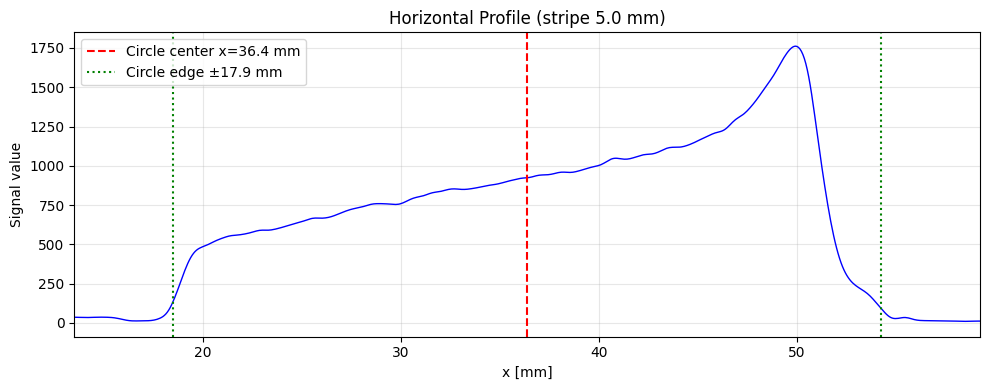

Saved to: C:\Users\grzanka\OneDrive - ifj.edu.pl\Projects\MB_foils\Publication_2026\raw_data\foils_mbo_aic144\2025-11-25\mbo_aic144_single_foil_rotated.npz


In [18]:
# Calculate horizontal profile through center (averaging central stripe)
stripe_px = int(PROFILE_STRIPE_MM / PIXEL_SIZE_MM / 2)
cy_opt_px = int(cy_mm / PIXEL_SIZE_MM)  # center Y in pixels (after rotation, center unchanged)
y0_stripe = max(0, cy_opt_px - stripe_px)
y1_stripe = min(h_opt, cy_opt_px + stripe_px)

h_profile_rotated = img_opt_smooth[y0_stripe:y1_stripe, :].mean(axis=0)
x_profile_mm = np.arange(len(h_profile_rotated)) * PIXEL_SIZE_MM

print(f"Horizontal profile: averaging Y=[{y0_stripe*PIXEL_SIZE_MM:.1f}, {y1_stripe*PIXEL_SIZE_MM:.1f}] mm ({y1_stripe-y0_stripe} px)")

# Plot profile
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_profile_mm, h_profile_rotated, 'b-', lw=1)
ax.axvline(cx_mm, c='r', ls='--', lw=1.5, label=f'Circle center x={cx_mm:.1f} mm')
ax.axvline(cx_mm - r_mm, c='g', ls=':', lw=1.5, label=f'Circle edge ±{r_mm:.1f} mm')
ax.axvline(cx_mm + r_mm, c='g', ls=':', lw=1.5)
ax.set(xlabel='x [mm]', ylabel='Signal value', title=f'Horizontal Profile (stripe {PROFILE_STRIPE_MM} mm)')
ax.set_xlim(cx_mm - r_mm - 5, cx_mm + r_mm + 5)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Save to npz file
output_file = DATA_PATH / 'mbo_aic144_single_foil_rotated.npz'
np.savez(output_file,
    image_rotated=img_optimized,
    image_rotated_smooth=img_opt_smooth,
    profile_x_mm=x_profile_mm,
    profile_values=h_profile_rotated,
    rotation_angle_deg=best_angle,
    pixel_size_mm=PIXEL_SIZE_MM,
    circle_center_x_mm=cx_mm,
    circle_center_y_mm=cy_mm,
    circle_radius_mm=r_mm
)
print(f"Saved to: {output_file}")